# Quantium Data Analytics Project - Task 1

## 1. UNDERSTAND THE PROBLEM STATEMENT AND BUSINESS CASE

You are part of Quantium’s retail analytics team and have been approached by your client, the Category Manager for chips, who wants to better understand the types of customers who purchase chips and their purchasing behaviour within the region.

The insights from your analysis will feed into the supermarket’s strategic plan for the chip category in the next half year.

**Main Tasks**

* Examine transaction data – look for inconsistencies, missing data across the data set, outliers, correctly identified category items, numeric data across all tables. If you determine any anomalies make the necessary changes in the dataset and save it. Having clean data will help when it comes to your analysis.

* Examine customer data – check for similar issues in the customer data, look for nulls and when you are happy merge the transaction and customer data together so it’s ready for the analysis ensuring you save your files along the way.

* Data analysis and customer segments – in your analysis make sure you define the metrics – look at total sales, drivers of sales, where the highest sales are coming from etc. Explore the data, create charts and graphs as well as noting any interesting trends and/or insights you find. These will all form part of our report to Julia.

* Deep dive into customer segments – define your recommendation from your insights, determine which segments we should be targeting, if packet sizes are relative and form an overall conclusion based on your analysis.

* Make sure you save your analysis in the CSV files and your visualisations – we will need them for our report. If you could work on this analysis and send me your initial findings by end of next week that would be great.  

## 2. IMPORT LIBRARIES AND READ DATASETS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import warnings
warnings.filterwarnings("ignore")

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from sklearn.preprocessing import OneHotEncoder

In [ ]:
customer_data = pd.read_csv('QVI_purchase_behaviour.csv')
trans_data = pd.read_excel('QVI_transaction_data.xlsx')

## 3. EXPLORATORY DATA ANALYSIS

In [ ]:
customer_data.shape

(72637, 3)

In [ ]:
customer_data.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [ ]:
customer_data.tail()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget
72636,2373711,YOUNG SINGLES/COUPLES,Mainstream


In [ ]:
trans_data.shape

(264836, 8)

In [ ]:
trans_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [ ]:
trans_data.tail()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8
264835,43365,272,272380,270189,74,Tostitos Splash Of Lime 175g,2,8.8


In [ ]:
# Check for null values

In [ ]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [ ]:
customer_data.isna().any()

,0
LYLTY_CARD_NBR,False
LIFESTAGE,False
PREMIUM_CUSTOMER,False


### Examine Transaction Data

In [ ]:
trans_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [ ]:
trans_data.isna().sum()

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0


In [ ]:
# Check data for duplicate values

In [ ]:
customer_data.duplicated().sum()

np.int64(0)

In [ ]:
trans_data.duplicated().sum()

np.int64(1)

In [ ]:
# Remove duplicates

In [ ]:
trans_data.drop_duplicates(inplace=True)

In [ ]:
# keep a copy of transcation dataframe
trans_df = trans_data.copy()

In [ ]:
# Convert Date format to datetime
trans_df['DATE'] = pd.to_datetime(trans_df['DATE'], unit='D', origin='1899-12-30')
trans_df

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [ ]:
# Check Summary Statistics

In [ ]:
trans_df.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264835,264835.000000,2.648350e+05,2.648350e+05,264835.000000,264835.000000,264835.000000
mean,2018-12-30 00:52:42.252722944,135.080216,1.355496e+05,1.351584e+05,56.583201,1.907308,7.304205
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.000000,7.002100e+04,6.760100e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.000000,1.303580e+05,1.351380e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030945e+05,2.027015e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.784306,8.058011e+04,7.813316e+04,32.826692,0.643655,3.083231


In [ ]:
# View all uniques enteries in Product Name
trans_df['PROD_NAME'].unique()

array(['Natural Chip        Compny SeaSalt175g',
       'CCs Nacho Cheese    175g',
       'Smiths Crinkle Cut  Chips Chicken 170g',
       'Smiths Chip Thinly  S/Cream&Onion 175g',
       'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
       'Old El Paso Salsa   Dip Tomato Mild 300g',
       'Smiths Crinkle Chips Salt & Vinegar 330g',
       'Grain Waves         Sweet Chilli 210g',
       'Doritos Corn Chip Mexican Jalapeno 150g',
       'Grain Waves Sour    Cream&Chives 210G',
       'Kettle Sensations   Siracha Lime 150g',
       'Twisties Cheese     270g', 'WW Crinkle Cut      Chicken 175g',
       'Thins Chips Light&  Tangy 175g', 'CCs Original 175g',
       'Burger Rings 220g', 'NCC Sour Cream &    Garden Chives 175g',
       'Doritos Corn Chip Southern Chicken 150g',
       'Cheezels Cheese Box 125g', 'Smiths Crinkle      Original 330g',
       'Infzns Crn Crnchers Tangy Gcamole 110g',
       'Kettle Sea Salt     And Vinegar 175g',
       'Smiths Chip Thinly  Cut Original 175g', 'K

We want to check that the products are only chips by counting the word frequencies in the product names. To make it clear, we need to remove the digits and symbols from the product names.

In [ ]:
# Remove digits and symbols from the Product Names
product = trans_df['PROD_NAME'].str.replace(r'[0-9]+[gG]', '', regex=True)
product = product.str.replace(r'&',' ')

In [ ]:
product.head(10)

,PROD_NAME
0,Natural Chip Compny SeaSalt
1,CCs Nacho Cheese
2,Smiths Crinkle Cut Chips Chicken
3,Smiths Chip Thinly S/Cream Onion
4,Kettle Tortilla ChpsHny Jlpno Chili
5,Old El Paso Salsa Dip Tomato Mild
6,Smiths Crinkle Chips Salt Vinegar
7,Grain Waves Sweet Chilli
8,Doritos Corn Chip Mexican Jalapeno
9,Grain Waves Sour Cream Chives


In [ ]:
# Count product name frequency
p_count = pd.Series(' '.join(product).split()).value_counts()

with pd.option_context('display.max_rows', None):
  display(p_count)

,count
Chips,49770
Kettle,41288
Smiths,28859
Salt,27976
Cheese,27890
Pringles,25102
Doritos,24962
Crinkle,23960
Corn,22063
Original,21560


Remove enteries containg 'Salsa' to ensure we only have data for Chips

In [ ]:
# Remove Salsa from Product name
trans_df = trans_df[trans_df['PROD_NAME'].str.contains(r'[Ss]alsa') == False]

In [ ]:
trans_df.shape

(246741, 8)

In [ ]:
# Check Summary Statistics of Transaction DataFrame (See if there are any Outliers)
trans_df.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246741,246741.000000,2.467410e+05,2.467410e+05,246741.000000,246741.000000,246741.000000
mean,2018-12-30 01:19:32.745510656,135.051212,1.355311e+05,1.351312e+05,56.351835,1.908061,7.321328
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756900e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351840e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030840e+05,2.026540e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.787231,8.071542e+04,7.814786e+04,33.695488,0.659832,3.077833


In [ ]:
# Check who made transaction of 200 packs
trans_df[trans_df['PROD_QTY'] == 200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [ ]:
# What other transactions made by same person
trans_df[trans_df['LYLTY_CARD_NBR'] == 226000]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


No other transaction made by this person, probably an outlier. Remove this from Dataset

In [ ]:
trans_df = trans_df[trans_df['LYLTY_CARD_NBR'] != 226000]
trans_df.shape

(246739, 8)

In [ ]:
# Check Summary Statistics again
trans_df.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246739,246739.000000,2.467390e+05,2.467390e+05,246739.000000,246739.000000,246739.000000
mean,2018-12-30 01:19:29.982856448,135.050474,1.355304e+05,1.351305e+05,56.352259,1.906456,7.316118
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756850e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351820e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030835e+05,2.026525e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000
std,NaN,76.787105,8.071534e+04,7.814774e+04,33.695295,0.342500,2.474901


In [ ]:
# Check transaction by date
count_days = trans_df.groupby(trans_df['DATE'].dt.date).size().reset_index(name='COUNT')
count_days.shape

(364, 2)

Looks like there is one missing date.

In [ ]:
# Check the range of dates by sorting
trans_df.sort_values(by='DATE')

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
34570,2018-07-01,28,28041,24771,2,Cobs Popd Sour Crm &Chives Chips 110g,2,7.6
259212,2018-07-01,19,19180,16403,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,2,9.2
217565,2018-07-01,7,7139,6843,75,Cobs Popd Sea Salt Chips 110g,1,3.8
13619,2018-07-01,191,191122,192479,20,Doritos Cheese Supreme 330g,2,11.4
27613,2018-07-01,225,225011,224717,32,Kettle Sea Salt And Vinegar 175g,2,10.8
...,...,...,...,...,...,...,...,...
174727,2019-06-30,57,57185,52337,106,Natural ChipCo Hony Soy Chckn175g,2,6.0
244035,2019-06-30,71,71070,69372,5,Natural Chip Compny SeaSalt175g,2,6.0
223440,2019-06-30,147,147201,146941,10,RRD SR Slow Rst Pork Belly 150g,2,5.4
8777,2019-06-30,80,80050,78475,70,Tyrrells Crisps Lightly Salted 165g,2,8.4


Dates range from July 01, 2018 to June 30, 2019. Check through the years which day is missing fro this dataset.

In [ ]:
count_date = trans_df.groupby('DATE').size()
pd.date_range(start = '2018-07-01', end = '2019-06-30').difference(count_date.index)

DatetimeIndex(['2018-12-25'], dtype='datetime64[ns]', freq='D')

The missing date is Christmas day, so it is expected that there are no sales on this day.

In [ ]:
# Get a new column for size of Chips Packet
trans_df['PACK_SIZE'] = (trans_df['PROD_NAME'].str.extract(r'(\d+)').astype(float))

In [ ]:
trans_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0


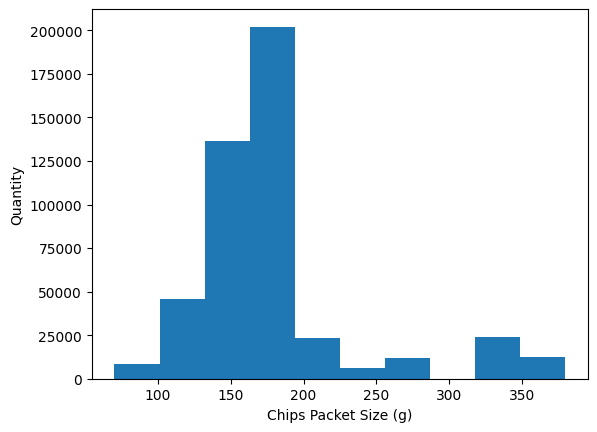

In [ ]:
# Visualize Pack Size Distribution
plt.hist(trans_df['PACK_SIZE'], weights=trans_df['PROD_QTY'])
plt.xlabel('Chips Packet Size (g)')
plt.ylabel('Quantity')
plt.show()

In [ ]:
# Create a new column to extract the Chips Brand name
trans_df['BRAND_NAME'] = trans_df['PROD_NAME'].str.split().str[0]
trans_df

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,Natural
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCs
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,Smiths
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,Smiths
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,Kettle
...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,175.0,Kettle
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,175.0,Tostitos
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,170.0,Doritos
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,150.0,Doritos


In [ ]:
# Get all unique brand names in the dataframe
trans_df['BRAND_NAME'].unique()

array(['Natural', 'CCs', 'Smiths', 'Kettle', 'Grain', 'Doritos',
       'Twisties', 'WW', 'Thins', 'Burger', 'NCC', 'Cheezels', 'Infzns',
       'Red', 'Pringles', 'Dorito', 'Infuzions', 'Smith', 'GrnWves',
       'Tyrrells', 'Cobs', 'French', 'RRD', 'Tostitos', 'Cheetos',
       'Woolworths', 'Snbts', 'Sunbites'], dtype=object)

In [ ]:
# Create a function to identify the string replacements needed.
def replace_brandname(line):
    name = line['BRAND_NAME']
    if name == "Infzns":
        return "Infuzions"
    elif name == "Red":
        return "Red Rock Deli"
    elif name == "RRD":
        return "Red Rock Deli"
    elif name == "Grain":
        return "Grain Waves"
    elif name == "GrnWves":
        return "Grain Waves"
    elif name == "Snbts":
        return "Sunbites"
    elif name == "Natural":
        return "Natural Chip Co"
    elif name == "NCC":
        return "Natural Chip Co"
    elif name == "WW":
        return "Woolworths"
    elif name == "Smith":
        return "Smiths"
    elif name == "Dorito":
        return "Doritos"
    else:
        return name

# Then apply the function to clean the brand names
trans_df["BRAND_NAME"] = trans_df.apply(lambda line: replace_brandname(line), axis=1)

# Check that there are no duplicate brands
trans_df["BRAND_NAME"].unique()

array(['Natural Chip Co', 'CCs', 'Smiths', 'Kettle', 'Grain Waves',
       'Doritos', 'Twisties', 'Woolworths', 'Thins', 'Burger', 'Cheezels',
       'Infuzions', 'Red Rock Deli', 'Pringles', 'Tyrrells', 'Cobs',
       'French', 'Tostitos', 'Cheetos', 'Sunbites'], dtype=object)

The brand names make sense now.
Next, we want to examine the customer data. We can generate summaries and check the categories in this dataset.

### Examine Customer Data

In [ ]:
# make a copy of customer data first
cust_df = customer_data.copy()
cust_df.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [ ]:
# Rename Premium Customer
cust_df = cust_df.rename(columns={'PREMIUM_CUSTOMER': 'MEMBER_TYPE'})

In [ ]:
cust_df.head()

,LYLTY_CARD_NBR,LIFESTAGE,MEMBER_TYPE
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [ ]:
# Check unique Member Types
cust_df['MEMBER_TYPE'].unique()

array(['Premium', 'Mainstream', 'Budget'], dtype=object)

In [ ]:
# Check unique LIFESTAGE
cust_df['LIFESTAGE'].unique()

array(['YOUNG SINGLES/COUPLES', 'YOUNG FAMILIES', 'OLDER SINGLES/COUPLES',
       'MIDAGE SINGLES/COUPLES', 'NEW FAMILIES', 'OLDER FAMILIES',
       'RETIREES'], dtype=object)

## Merge Transaction data to Customer Data

In [ ]:
# Join Customer and Transaction datasets
merged_df = trans_df.set_index('LYLTY_CARD_NBR').join(cust_df.set_index('LYLTY_CARD_NBR'))
merged_df = merged_df.reset_index()
merged_df = merged_df.sort_values(by='DATE').reset_index(drop=True)
merged_df

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME,LIFESTAGE,MEMBER_TYPE
0,28041,2018-07-01,28,24771,2,Cobs Popd Sour Crm &Chives Chips 110g,2,7.6,110.0,Cobs,OLDER FAMILIES,Budget
1,19180,2018-07-01,19,16403,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,2,9.2,150.0,Kettle,YOUNG SINGLES/COUPLES,Premium
2,7139,2018-07-01,7,6843,75,Cobs Popd Sea Salt Chips 110g,1,3.8,110.0,Cobs,YOUNG FAMILIES,Premium
3,191122,2018-07-01,191,192479,20,Doritos Cheese Supreme 330g,2,11.4,330.0,Doritos,MIDAGE SINGLES/COUPLES,Mainstream
4,225011,2018-07-01,225,224717,32,Kettle Sea Salt And Vinegar 175g,2,10.8,175.0,Kettle,NEW FAMILIES,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...
246734,57185,2019-06-30,57,52337,106,Natural ChipCo Hony Soy Chckn175g,2,6.0,175.0,Natural Chip Co,RETIREES,Premium
246735,71070,2019-06-30,71,69372,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,Natural Chip Co,YOUNG SINGLES/COUPLES,Mainstream
246736,147201,2019-06-30,147,146941,10,RRD SR Slow Rst Pork Belly 150g,2,5.4,150.0,Red Rock Deli,YOUNG FAMILIES,Premium
246737,80050,2019-06-30,80,78475,70,Tyrrells Crisps Lightly Salted 165g,2,8.4,165.0,Tyrrells,MIDAGE SINGLES/COUPLES,Mainstream


In [ ]:
# Check for null values
merged_df.isna().sum()

,0
LYLTY_CARD_NBR,0
DATE,0
STORE_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0
PACK_SIZE,0
BRAND_NAME,0


In [ ]:
# Check for duplicate values
merged_df.duplicated().sum()

np.int64(0)

In [ ]:
# Save this dataset as a csv file
merged_df.to_csv('QVI_merged_data.csv')

In [ ]:
merged_df = pd.read_csv('QVI_merged_data.csv')

## Data Analysis on Customers Segments

Now that the data has been cleaned, we want to look for insights in the chip market to help recommend a business strategy.

To do so, some metrics we want to consider are:
* Who spends the most on chips (total sales), describing customers by lifestage and their general purchasing behaviour
* How many customers are in each segment
* How many chips are bought per customer by segment
* What's the average chip price by customer segment

We could also ask our data team for more information. Examples are:
- The customer's total spend over the period and total spend for each transaction
to understand what proportion of their grocery spend is on chips
- Proportion of customers in each customer segment overall to compare against the
mix of customers who purchase chips

Let's start with calculating total sales by LIFESTAGE and PREMIUM_CUSTOMER and plotting the split by these segments to describe which customer segment
contribute most to chip sales.

In [ ]:
# Calculate total Sales by LIFESTAGE and MEMBER TYPE
cust_total_sales = merged_df.groupby(['LIFESTAGE', 'MEMBER_TYPE'], as_index=False)['TOT_SALES'].agg(['sum'])
cust_total_sales = cust_total_sales.rename(columns={'sum':'sum_total_sales'})
cust_total_sales.sort_values(by = 'sum_total_sales', ascending=False)

,LIFESTAGE,MEMBER_TYPE,sum_total_sales
6,OLDER FAMILIES,Budget,156863.75
19,YOUNG SINGLES/COUPLES,Mainstream,147582.20
13,RETIREES,Mainstream,145168.95
15,YOUNG FAMILIES,Budget,129717.95
9,OLDER SINGLES/COUPLES,Budget,127833.60
10,OLDER SINGLES/COUPLES,Mainstream,124648.50
11,OLDER SINGLES/COUPLES,Premium,123531.55
12,RETIREES,Budget,105916.30
7,OLDER FAMILIES,Mainstream,96413.55
14,RETIREES,Premium,91296.65


In [ ]:
# total sales
total_sales = merged_df['TOT_SALES'].sum()
total_sales

np.float64(1805171.7000000004)

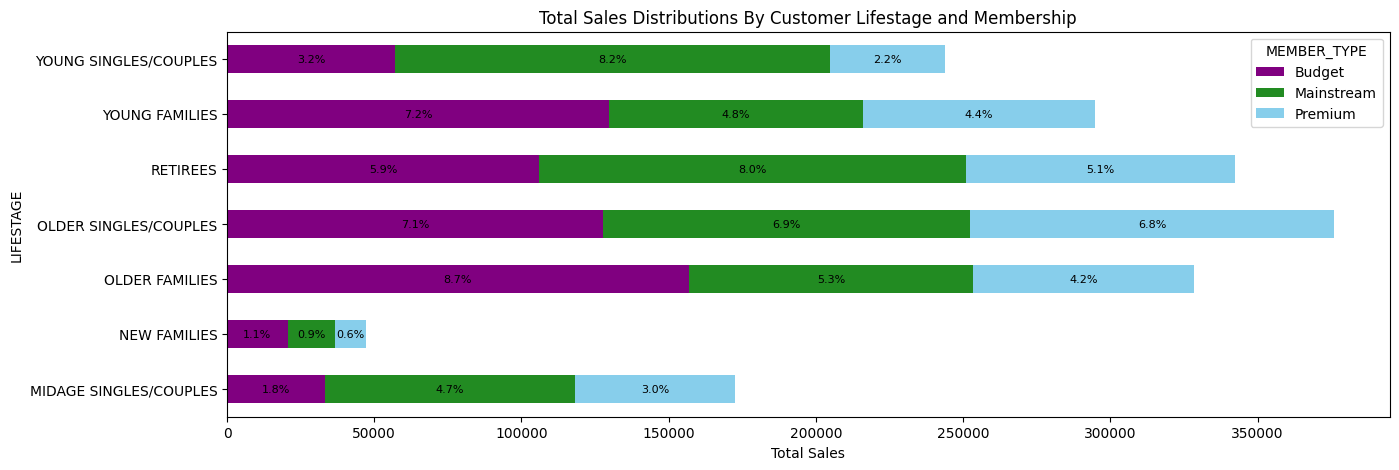

In [ ]:
# Plot a distribution of the TOTAL SALES by lifestage and member type
total_sales_dist = merged_df.pivot_table(
    index='LIFESTAGE',
    columns='MEMBER_TYPE',
    values='TOT_SALES',
    aggfunc='sum',
    fill_value=0
)
ax = total_sales_dist.plot(kind='barh', stacked=True, color=['purple', 'forestgreen', 'skyblue'], figsize=(15, 5))

# Add percentages of the summed total sales as labels to each bar
for rect in ax.patches:
    # Find where everything is located
    height = rect.get_height()
    width = rect.get_width()
    label = width / total_sales * 100
    x = rect.get_x()
    y = rect.get_y()

    label_text = f'{(label):.1f}%'

    # Set label positions
    label_x = x + width / 2
    label_y = y + height / 2

    # only plot labels greater than given width
    if width > 0:
        ax.text(label_x, label_y, label_text, ha='center', va='center', fontsize=8)

ax.set_xlabel("Total Sales")
ax.set_title('Total Sales Distributions By Customer Lifestage and Membership')
plt.show()

Most sales are from Older families - Budget, Young singles/couples - Mainstream and Retirees - Mainstream. We can see if this is because of the customer numbers in each segment.

In [ ]:
# Check if all customers made chip purchase
len(cust_df['LYLTY_CARD_NBR'].unique()) == len(merged_df['LYLTY_CARD_NBR'].unique())

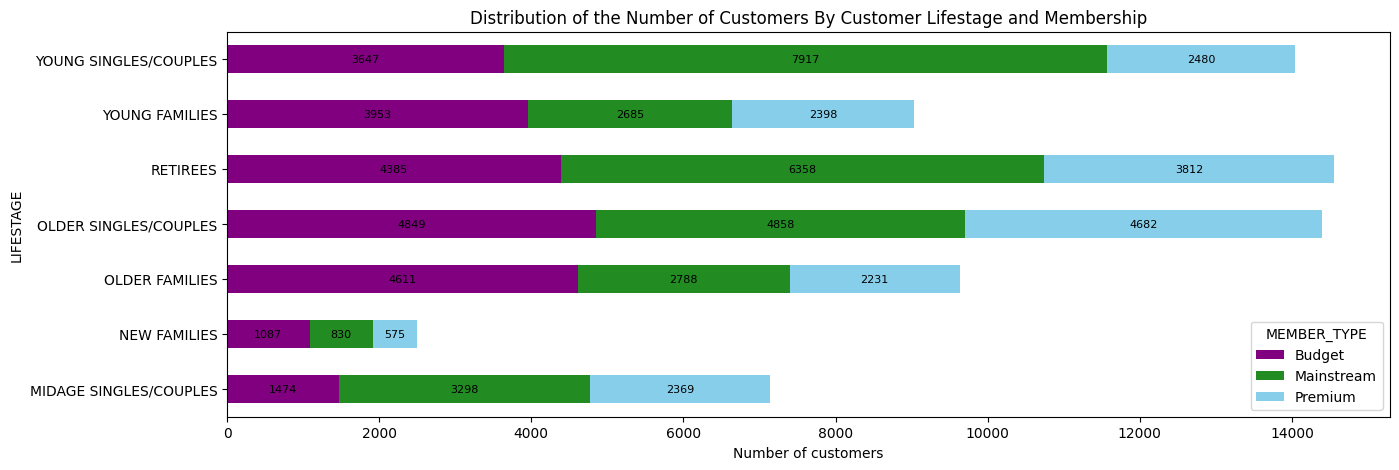

In [ ]:
# Plot the numbers of customers in each segment by counting the unique LYLTY_CARD_NBR entries
sum_customers= merged_df.groupby(['LIFESTAGE','MEMBER_TYPE'])['LYLTY_CARD_NBR'].agg('nunique').unstack('MEMBER_TYPE').fillna(0)
ax = sum_customers.plot(kind='barh', stacked=True, color=['purple', 'forestgreen', 'skyblue'], figsize=(15, 5))

# Add customer numbers as labels to each bar
# .patches is everything inside of the chart
for rect in ax.patches:
    # Find where everything is located
    height = rect.get_height()
    width = rect.get_width()
    x = rect.get_x()
    y = rect.get_y()

    label_text = f'{(width):.0f}'

    # Set label positions
    label_x = x + width / 2
    label_y = y + height / 2

    # only plot labels greater than given width
    if width > 0:
        ax.text(label_x, label_y, label_text, ha='center', va='center', fontsize=8)

ax.set_xlabel("Number of customers")
ax.set_title('Distribution of the Number of Customers By Customer Lifestage and Membership')
plt.show()

There are more Young singles/couples - mainstream and Retirees - mainstream who buy chips. This contributes to there being more sales to these customer segments but this is not a major driver for the Older families - budget segment.

We can then take a look at the total and average units of chips bought per customer by LIFESTAGE and MEMBER_TYPE.

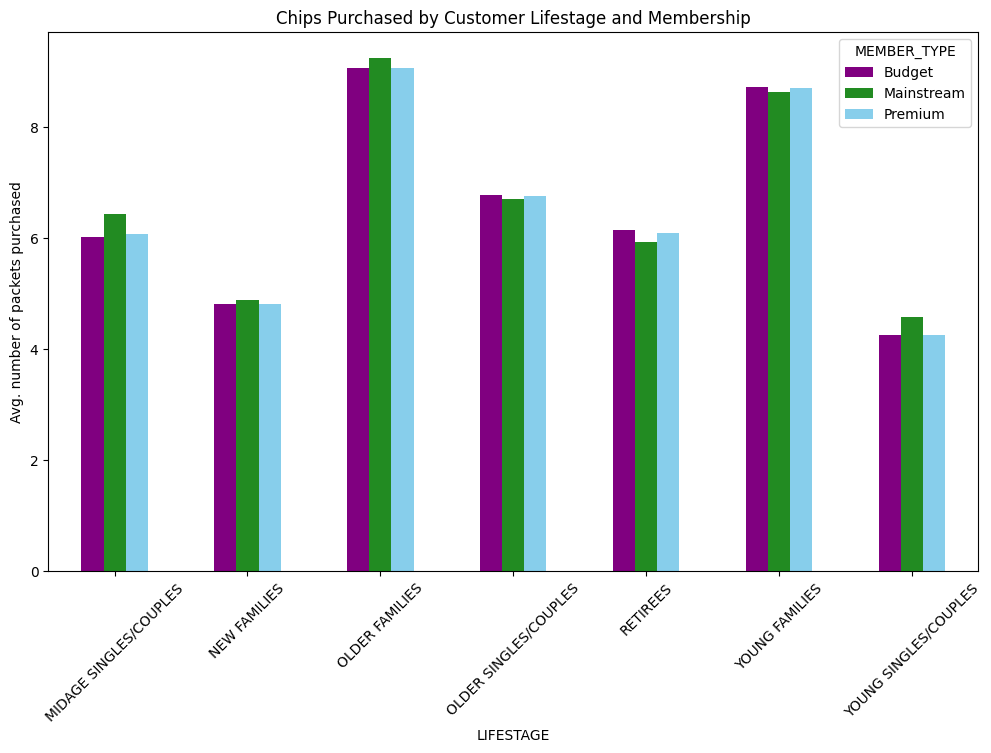

In [ ]:
# Plot the average number of chip packets bought per customer by LIFESTAGE and MEMBER_TYPE
no_packets_data = merged_df.groupby(['LIFESTAGE','MEMBER_TYPE'])['PROD_QTY'].sum()/merged_df.groupby(['LIFESTAGE','MEMBER_TYPE'])['LYLTY_CARD_NBR'].nunique(0)
ax = no_packets_data.unstack('MEMBER_TYPE').fillna(0).plot.bar(stacked = False, color=['purple', 'forestgreen', 'skyblue'], figsize=(12, 7))
ax.set_ylabel("Avg. number of packets purchased")
ax.set_title('Chips Purchased by Customer Lifestage and Membership')
plt.xticks(rotation=45)
plt.show()

Older families and young families in general buy more chips per customer.

In [ ]:
# Investigate the average price per unit sold by LIFESTAGE and MEMBER_TYPE

In [ ]:
# Create a new column for the unit price of chips purchased per transaction
merged_df['UNIT_PRICE'] = merged_df['TOT_SALES']/merged_df['PROD_QTY']

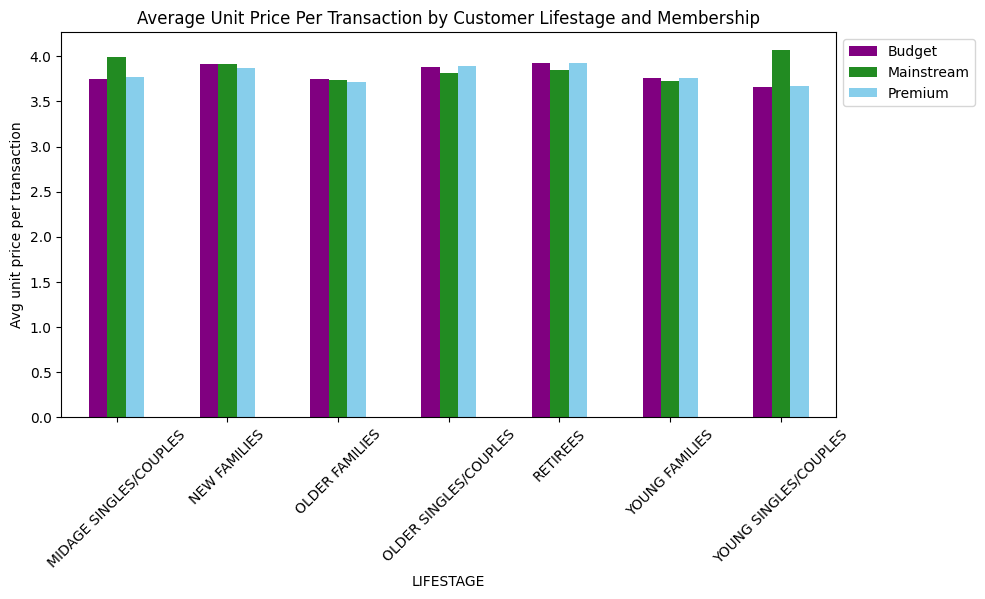

In [ ]:
# Plot the distribution of the average unit price per transaction by LIFESTAGE and MEMBER_TYPE
avg_price_per_unit = merged_df.pivot_table(
    index='LIFESTAGE',
    columns='MEMBER_TYPE',
    values='UNIT_PRICE',
    aggfunc='mean',
    fill_value=0
)
ax = avg_price_per_unit.plot.bar(stacked=False, color=['purple', 'forestgreen', 'skyblue'], figsize=(10, 5))

ax.set_ylabel("Avg unit price per transaction")
ax.set_title('Average Unit Price Per Transaction by Customer Lifestage and Membership')

plt.legend(loc = "upper left",bbox_to_anchor=(1.0, 1.0))
plt.xticks(rotation=45)

plt.show()

For young and midage singles/couples, the mainstream group are more willing to pay more for a packet of chips than their budget and premium counterpart. Given the total sales, as well as the number of customers buying chips, is higher in these groups compared to the non-mainstream groups, this suggests that chips may not be the choice of snack for these groups. Further information on shopping habits would be useful in this case.

In [ ]:
# Perform an independent t-test between mainstream vs premium and budget midage and young singles and couples

In [ ]:
# Defien the groups to test the hypthesis
mainstream = merged_df["MEMBER_TYPE"] == "Mainstream"
young_midage = (merged_df["LIFESTAGE"] == "MIDAGE SINGLES/COUPLES") | (merged_df["LIFESTAGE"] == "YOUNG SINGLES/COUPLES")
premium_budget = merged_df["MEMBER_TYPE"] != "Mainstream"

group1 = merged_df[mainstream & young_midage]["UNIT_PRICE"]
group2 = merged_df[premium_budget & young_midage]["UNIT_PRICE"]

# Generate the t-test
stat, pval = ttest_ind(group1.values, group2.values, equal_var=False)

print(pval, stat)

6.967354232966616e-306 37.6243885962297


The p-value is close to 0, it means that that the null hypothesis is rejected, which is average price unit between the mainstream and premium/budget groups for young/midage singles/couples is the same.
In conclusion, unit price for mainstream, young and mid-age singles and couples are significantly higher than that of budget or premium, young and midage singles and couples.

## Deep dive into specific customer segments for insights

In [ ]:
# Next, analyze the customer segment that contribute the most to sale. It is needed to further increase sale or retain the customer segment.
# Bases on the analysis above, we will analyze Mainstream - young singles/couples.

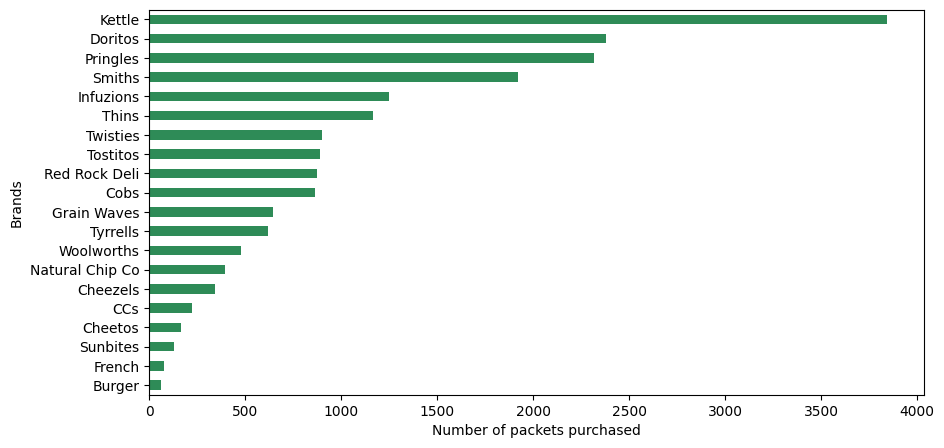

In [ ]:
young_mainstream = merged_df.loc[merged_df['LIFESTAGE'] == "YOUNG SINGLES/COUPLES"]
young_mainstream = young_mainstream.loc[young_mainstream['MEMBER_TYPE'] == "Mainstream"]
ax = young_mainstream["BRAND_NAME"].value_counts().sort_values(ascending = True).plot.barh(figsize=(10, 5), color='seagreen')

ax.set_xlabel("Number of packets purchased")
ax.set_ylabel("Brands")

plt.show()

In [ ]:
# Create copy of df for quick reset
temp = merged_df.copy()
temp["group"] = temp["LIFESTAGE"] + ' - ' + temp['MEMBER_TYPE']

In [ ]:
temp

,Unnamed: 0,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME,LIFESTAGE,MEMBER_TYPE,UNIT_PRICE,group
0,0,28041,2018-07-01,28,24771,2,Cobs Popd Sour Crm &Chives Chips 110g,2,7.6,110.0,Cobs,OLDER FAMILIES,Budget,3.8,OLDER FAMILIES - Budget
1,1,19180,2018-07-01,19,16403,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,2,9.2,150.0,Kettle,YOUNG SINGLES/COUPLES,Premium,4.6,YOUNG SINGLES/COUPLES - Premium
2,2,7139,2018-07-01,7,6843,75,Cobs Popd Sea Salt Chips 110g,1,3.8,110.0,Cobs,YOUNG FAMILIES,Premium,3.8,YOUNG FAMILIES - Premium
3,3,191122,2018-07-01,191,192479,20,Doritos Cheese Supreme 330g,2,11.4,330.0,Doritos,MIDAGE SINGLES/COUPLES,Mainstream,5.7,MIDAGE SINGLES/COUPLES - Mainstream
4,4,225011,2018-07-01,225,224717,32,Kettle Sea Salt And Vinegar 175g,2,10.8,175.0,Kettle,NEW FAMILIES,Budget,5.4,NEW FAMILIES - Budget
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246734,246734,57185,2019-06-30,57,52337,106,Natural ChipCo Hony Soy Chckn175g,2,6.0,175.0,Natural Chip Co,RETIREES,Premium,3.0,RETIREES - Premium
246735,246735,71070,2019-06-30,71,69372,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,Natural Chip Co,YOUNG SINGLES/COUPLES,Mainstream,3.0,YOUNG SINGLES/COUPLES - Mainstream
246736,246736,147201,2019-06-30,147,146941,10,RRD SR Slow Rst Pork Belly 150g,2,5.4,150.0,Red Rock Deli,YOUNG FAMILIES,Premium,2.7,YOUNG FAMILIES - Premium
246737,246737,80050,2019-06-30,80,78475,70,Tyrrells Crisps Lightly Salted 165g,2,8.4,165.0,Tyrrells,MIDAGE SINGLES/COUPLES,Mainstream,4.2,MIDAGE SINGLES/COUPLES - Mainstream


In [ ]:
# Let's do market basket analysis by doing apriori algorithm

In [ ]:
groups = pd.get_dummies(temp["group"])
brands = pd.get_dummies(temp["BRAND_NAME"])
groups_brands = groups.join(brands)
groups_brands = groups_brands.astype(int)
groups_brands

,MIDAGE SINGLES/COUPLES - Budget,MIDAGE SINGLES/COUPLES - Mainstream,MIDAGE SINGLES/COUPLES - Premium,NEW FAMILIES - Budget,NEW FAMILIES - Mainstream,NEW FAMILIES - Premium,OLDER FAMILIES - Budget,OLDER FAMILIES - Mainstream,OLDER FAMILIES - Premium,OLDER SINGLES/COUPLES - Budget,...,Natural Chip Co,Pringles,Red Rock Deli,Smiths,Sunbites,Thins,Tostitos,Twisties,Tyrrells,Woolworths
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246734,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
246735,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
246736,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
246737,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
freq_groups_brands = apriori(groups_brands, min_support=0.008, use_colnames=True)
rules = association_rules(freq_groups_brands, metric="lift", min_threshold=0.5)
rules.sort_values('confidence', ascending=False, inplace=True)


In [ ]:
freq_groupsbrands = apriori(groups_brands, min_support=0.009, use_colnames=True)
rules = association_rules(freq_groupsbrands, metric="lift", min_threshold=0.5)
rules.sort_values('confidence', ascending = False, inplace = True)

In [ ]:
set_temp = temp["group"].unique()
rules[rules['antecedents'].apply(lambda x: list(x)).apply(lambda x: x in set_temp)]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
23,(YOUNG SINGLES/COUPLES - Mainstream),(Kettle),0.079209,0.167335,0.015579,0.196684,1.175395,1.0,0.002325,1.036536,0.162059,0.067453,0.035248,0.144893
11,(RETIREES - Budget),(Kettle),0.057652,0.167335,0.010505,0.182214,1.088922,1.0,0.000858,1.018195,0.086656,0.048979,0.017870,0.122496
5,(OLDER SINGLES/COUPLES - Budget),(Kettle),0.069596,0.167335,0.012422,0.178488,1.066654,1.0,0.000776,1.013577,0.067163,0.055330,0.013395,0.126361
9,(OLDER SINGLES/COUPLES - Premium),(Kettle),0.067111,0.167335,0.011944,0.177970,1.063555,1.0,0.000714,1.012937,0.064056,0.053679,0.012772,0.124673
13,(RETIREES - Mainstream),(Kettle),0.080936,0.167335,0.013723,0.169554,1.013265,1.0,0.000180,1.002673,0.014244,0.058508,0.002666,0.125782
6,(OLDER SINGLES/COUPLES - Mainstream),(Kettle),0.069146,0.167335,0.011490,0.166168,0.993030,1.0,-0.000081,0.998601,-0.007483,0.051068,-0.001401,0.117416
17,(YOUNG FAMILIES - Budget),(Kettle),0.071991,0.167335,0.011117,0.154422,0.922834,1.0,-0.000930,0.984729,-0.082658,0.048714,-0.015508,0.110429
1,(OLDER FAMILIES - Budget),(Kettle),0.087193,0.167335,0.013456,0.154318,0.922212,1.0,-0.001135,0.984608,-0.084590,0.055815,-0.015632,0.117364
3,(OLDER FAMILIES - Budget),(Smiths),0.087193,0.123013,0.011948,0.137027,1.113927,1.0,0.001222,1.016240,0.112045,0.060264,0.015980,0.117077
19,(YOUNG FAMILIES - Budget),(Smiths),0.071991,0.123013,0.009459,0.131397,1.068157,1.0,0.000604,1.009652,0.068758,0.050982,0.009560,0.104147


In [ ]:
rules[rules['antecedents'] == {'YOUNG SINGLES/COUPLES - Mainstream'}]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
23,(YOUNG SINGLES/COUPLES - Mainstream),(Kettle),0.079209,0.167335,0.015579,0.196684,1.175395,1.0,0.002325,1.036536,0.162059,0.067453,0.035248,0.144893
20,(YOUNG SINGLES/COUPLES - Mainstream),(Doritos),0.079209,0.102229,0.009642,0.121725,1.190707,1.0,0.001544,1.022198,0.173940,0.056123,0.021716,0.108020
25,(YOUNG SINGLES/COUPLES - Mainstream),(Pringles),0.079209,0.101735,0.009382,0.118451,1.164306,1.0,0.001324,1.018962,0.153259,0.054688,0.018609,0.105337


From apriori analysis, we can see that for Mainstream - young singles/couples, Kettle is the brand of choice. This is also true for most other segments. We can use the affinity index to see if there are brands this segment prefers more than the other segments to target.

In [ ]:
# find the target rating proportion
target_segment = young_mainstream["BRAND_NAME"].value_counts().sort_values(ascending = True).rename_axis('BRANDS').reset_index(name='target')
target_segment.target /= young_mainstream["PROD_QTY"].sum()

# find the other rating proportion
not_young_mainstream = merged_df.loc[merged_df['LIFESTAGE'] != "YOUNG SINGLES/COUPLES"]
not_young_mainstream = not_young_mainstream.loc[not_young_mainstream['MEMBER_TYPE'] != "Mainstream"]
other = not_young_mainstream["BRAND_NAME"].value_counts().sort_values(ascending = True).rename_axis('BRANDS').reset_index(name='other')
other.other /= not_young_mainstream["PROD_QTY"].sum()

# join the two dataframes
brand_proportions = target_segment.set_index('BRANDS').join(other.set_index('BRANDS'))
# full_df = trans_df.set_index('LYLTY_CARD_NBR').join(cust_df.set_index('LYLTY_CARD_NBR'))
brand_proportions = brand_proportions.reset_index()
brand_proportions['affinity'] = brand_proportions['target']/brand_proportions['other']
brand_proportions.sort_values(by = 'affinity', ascending = False)

,BRANDS,target,other,affinity
8,Tyrrells,0.017088,0.013368,1.278261
13,Twisties,0.024845,0.019633,1.265487
18,Doritos,0.065673,0.052512,1.250637
12,Tostitos,0.024569,0.019944,1.231902
19,Kettle,0.106115,0.086574,1.225703
17,Pringles,0.063906,0.052477,1.217784
10,Cobs,0.023851,0.020004,1.192284
15,Infuzions,0.034507,0.029931,1.152881
9,Grain Waves,0.017833,0.016214,1.099869
14,Thins,0.032188,0.029771,1.081164


By using the affinity index, we can see that mainstream young singles/couples are 28% more likely to purcahse Tyrrells chips than the other segments. However, they are 50% less likely to purchase Burger Rings.

We also want to find out if our target segment tends to buy larger packs of chips.

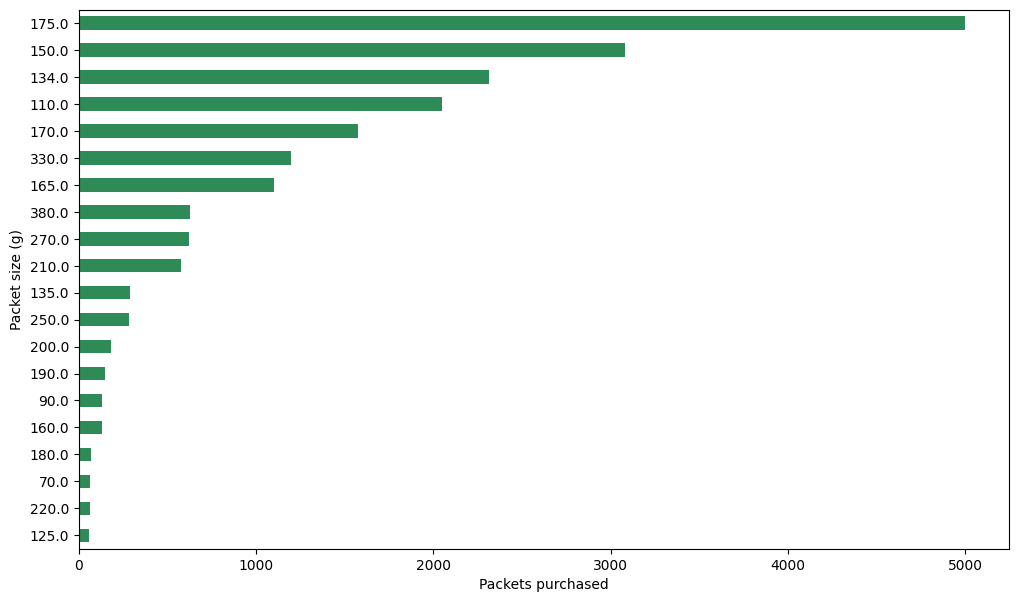

In [ ]:
# Plot the distribution of the packet sizes - what is most popular

young_mainstream = merged_df.loc[merged_df['LIFESTAGE'] == "YOUNG SINGLES/COUPLES"]
young_mainstream = young_mainstream.loc[young_mainstream['MEMBER_TYPE'] == "Mainstream"]

ax = young_mainstream["PACK_SIZE"].value_counts().sort_values(ascending = True).plot.barh(color='seagreen', figsize=(12,7))
ax.set_ylabel("Packet size (g)")
ax.set_xlabel("Packets purchased")

plt.show()

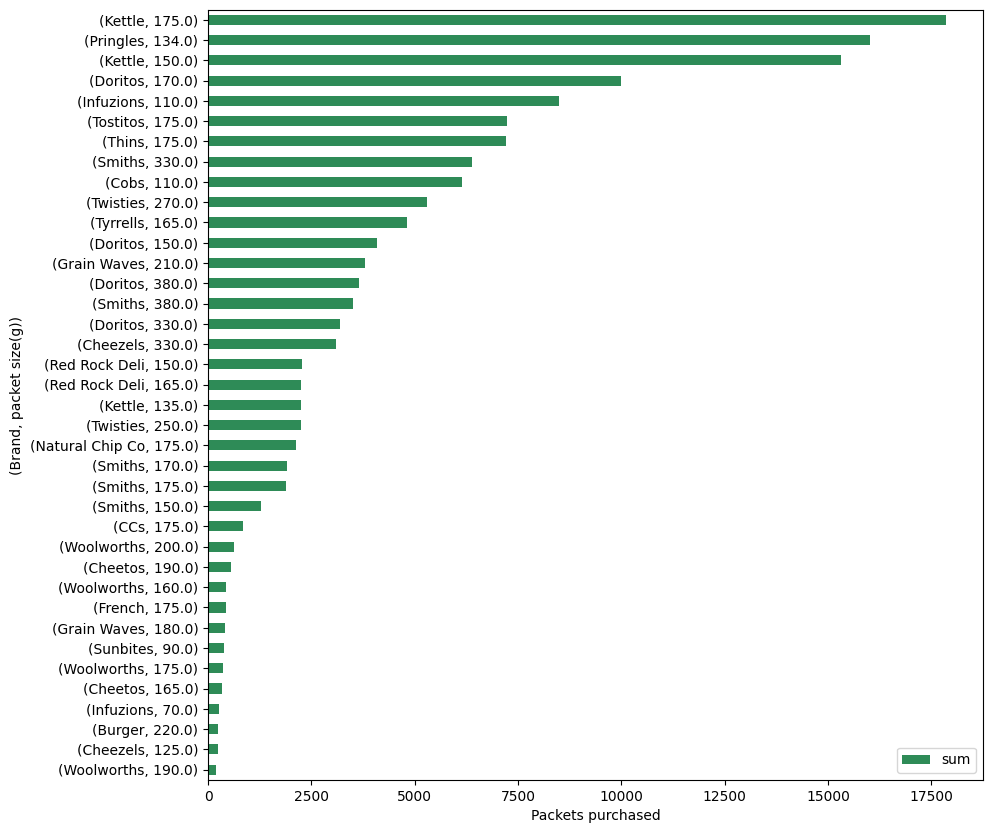

In [ ]:
# Also want to check which brands correspond to what packet sizes
# Also want to check which brands correspond to what sized packets.
brand_size = young_mainstream.groupby(['BRAND_NAME','PACK_SIZE'])['TOT_SALES'].agg(['sum'])
ax = brand_size.sort_values(by = 'sum').plot.barh(y = "sum", color='seagreen', figsize=(10,10))
ax.set_ylabel("(Brand, packet size(g))")
ax.set_xlabel("Packets purchased")
plt.show()

In [ ]:
# Run the apriori alogorithm again
groups = pd.get_dummies(temp["group"])
brands = pd.get_dummies(temp["PACK_SIZE"])
groups_brands = groups.join(brands)
groups_brands = groups_brands.astype(int)
groups_brands

,MIDAGE SINGLES/COUPLES - Budget,MIDAGE SINGLES/COUPLES - Mainstream,MIDAGE SINGLES/COUPLES - Premium,NEW FAMILIES - Budget,NEW FAMILIES - Mainstream,NEW FAMILIES - Premium,OLDER FAMILIES - Budget,OLDER FAMILIES - Mainstream,OLDER FAMILIES - Premium,OLDER SINGLES/COUPLES - Budget,...,175.0,180.0,190.0,200.0,210.0,220.0,250.0,270.0,330.0,380.0
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246734,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
246735,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
246736,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246737,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
freq_groups_brands = apriori(groups_brands, min_support=0.009, use_colnames=True)
rules = association_rules(freq_groups_brands, metric="lift", min_threshold=0.5)
rules.sort_values('confidence', ascending = False, inplace = True)
set_temp = temp["group"].unique()
rules[rules["antecedents"].apply(lambda x: list(x)).apply(lambda x: x in set_temp)]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
39,(YOUNG FAMILIES - Premium),(175.0),0.043706,0.269066,0.012150,0.278004,1.033221,1.0,0.000391,1.012381,0.033623,0.040418,0.012229,0.161581
34,(YOUNG FAMILIES - Budget),(175.0),0.071991,0.269066,0.019944,0.277037,1.029624,1.0,0.000574,1.011025,0.031004,0.062110,0.010905,0.175580
40,(YOUNG SINGLES/COUPLES - Budget),(175.0),0.034745,0.269066,0.009476,0.272717,1.013569,1.0,0.000127,1.005020,0.013869,0.032193,0.004995,0.153967
6,(OLDER FAMILIES - Mainstream),(175.0),0.053664,0.269066,0.014542,0.270977,1.007102,1.0,0.000103,1.002621,0.007451,0.047184,0.002614,0.162511
8,(OLDER FAMILIES - Premium),(175.0),0.042162,0.269066,0.011413,0.270691,1.006041,1.0,0.000069,1.002229,0.006269,0.038066,0.002224,0.156554
24,(RETIREES - Budget),(175.0),0.057652,0.269066,0.015591,0.270439,1.005105,1.0,0.000079,1.001883,0.005390,0.050113,0.001879,0.164193
30,(RETIREES - Premium),(175.0),0.049591,0.269066,0.013399,0.270186,1.004165,1.0,0.000056,1.001536,0.004364,0.043893,0.001533,0.159992
5,(OLDER FAMILIES - Budget),(175.0),0.087193,0.269066,0.023539,0.269964,1.003338,1.0,0.000078,1.001230,0.003644,0.070747,0.001229,0.178724
12,(OLDER SINGLES/COUPLES - Budget),(175.0),0.069596,0.269066,0.018745,0.269334,1.000996,1.0,0.000019,1.000367,0.001070,0.058592,0.000367,0.169499
20,(OLDER SINGLES/COUPLES - Premium),(175.0),0.067111,0.269066,0.018064,0.269159,1.000346,1.0,0.000006,1.000127,0.000371,0.056784,0.000127,0.168147


In [ ]:
# We will now see if the mainstream young singles/couples have certain preferences over other segments by using affinity index.

In [ ]:
# find the target rating proportion
target_segment = young_mainstream["PACK_SIZE"].value_counts().sort_values(ascending = True).rename_axis('SIZES').reset_index(name='target')
target_segment.target /= young_mainstream["PROD_QTY"].sum()

# find the other rating proportion
other = not_young_mainstream["PACK_SIZE"].value_counts().sort_values(ascending = True).rename_axis('SIZES').reset_index(name='other')
other.other /= not_young_mainstream["PROD_QTY"].sum()

# join the two dataframes
brand_proportions = target_segment.set_index('SIZES').join(other.set_index('SIZES'))
brand_proportions = brand_proportions.reset_index()
brand_proportions['affinity'] = brand_proportions['target']/brand_proportions['other']
brand_proportions.sort_values(by = 'affinity', ascending = False)

,SIZES,target,other,affinity
11,270.0,0.017115,0.012958,1.320816
12,380.0,0.017281,0.013375,1.291983
14,330.0,0.032988,0.026455,1.246958
10,210.0,0.015901,0.012973,1.225645
17,134.0,0.063906,0.052477,1.217784
16,110.0,0.056618,0.046653,1.213608
9,135.0,0.008006,0.006750,1.185942
8,250.0,0.007729,0.006674,1.158067
15,170.0,0.043478,0.041826,1.039494
18,150.0,0.085024,0.084969,1.000645


Based on the table, mainstream young singles/couples are 32% more likely to puchase 270g chips. But, they are less likely to buy chips which has 220g.
This finding is consistent with our other finding that the brand 'burger' with 220g is less likely to be purchased rather than 'twisties' that comes in 270g.

# Conclusion

The three highest contributing segments to the total sales are:

1. Older families - Budget
2. Young singles/couples - Mainstream
3. Retirees - Mainstream

The largest consumer group is mainstream young singles and couples, followed by mainstream retirees, which explains their high total sales. Although the number of people is not a major factor for budget older families, both older and young families generally buy more chips per person. Additionally, mainstream young singles and couples spend more per purchase compared to their non-mainstream counterparts, a difference that is statistically significant. Within the mainstream young singles and couples segment, they are 28% more likely to buy Tyrells chips compared to other segments.
This group also buys the most Kettles chips, a trend seen across most segments. However, they are 50% less likely to purchase Burger Rings, which is notable given that Burger Rings are the only chips available in a 220g size. Mainstream young singles and couples are also 32% more likely to choose 270g chips, like Twisties, compared to other segments. Across various segments, the 175g packet size is the most popular.

To target mainstream young singles and couples more effectively, consider placing Tyrells and Twisties where they are more likely to be noticed by this group. Since Kettles chips are the most popular overall, positioning Tyrells and Twisties near Kettles could be beneficial. This approach could also be applied to other segments that buy a lot of Kettles chips to boost their total sales.

In [ ]:
!jupyter nbconvert --to pdf "Quantium_DA_Task_1.ipynb"

[NbConvertApp] WARNING | pattern 'Quantium_DA_Task_1.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--exec